In [2]:
%matplotlib inline

%load_ext autoreload
%autoreload 2
import warnings
warnings.filterwarnings("ignore")

from pathlib import Path
from qvc.hubble.hubble_utils import load_cosmo_results_hdf5
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl
plt.style.use('../src/qvc/hubble/style.mplstyle')

In [ ]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt

results_dir = Path("../results/cosmo/apr28g")

rows = []

fields = ["cosmo_model", "logZ", "logZerr", "N", "z_f", 
          "Om0", "Om0_err_upper", "Om0_err_lower",
          "w0", "w0_err_upper", "w0_err_lower",
          "wa", "wa_err_upper", "wa_err_lower"]

for file_path in sorted(results_dir.rglob("*.hdf5")):
    if not file_path.is_file():
        continue

    result = load_cosmo_results_hdf5(str(file_path))

    for model in ["FlatLambdaCDM", "FlatwCDM", "Flatw0waCDM"]:
        row = {"cosmo_model": model}
        row.update({f: result[model].get(f, np.nan) for f in fields if f != "cosmo_model"})
        rows.append(row)

df = pd.DataFrame(rows)
df = df[df["N"].isin([1000, 3000, 5000, 7000])]
df = df.sort_values(["N", "z_f", "cosmo_model"]).reset_index(drop=True)

df["N"].unique()

array([1000, 3000])

In [10]:
result = load_cosmo_results_hdf5(str("../results/cosmo/apr28g/apr28g_uniform_grid_quick_N7000_zmax2.0/cosmo_results_N4199_z0p44_2p00.hdf5"))
result['FlatwCDM']['N']

np.int64(4199)

In [11]:
import numpy as np

def odds_sigmas_from_logZ(logZ_a, logZ_b, logZ_a_err, logZ_b_err):
    """
    Compute:
        delta     = logZ_a - logZ_b
        delta_err = sqrt(logZ_a_err^2 + logZ_b_err^2)   [independent errors]
        sigma     = sqrt(2 * |delta|)
        sigma_err = delta_err / sqrt(2 * |delta|)

    Returns
    -------
    delta, delta_err, sigma, sigma_err
    """
    logZ_a = np.asarray(logZ_a, dtype=float)
    logZ_b = np.asarray(logZ_b, dtype=float)
    logZ_a_err = np.asarray(logZ_a_err, dtype=float)
    logZ_b_err = np.asarray(logZ_b_err, dtype=float)

    delta = logZ_a - logZ_b
    delta_err = np.sqrt(logZ_a_err**2 + logZ_b_err**2)

    abs_delta = np.abs(delta)
    sigma = np.sqrt(2.0 * abs_delta)

    sigma_err = np.full_like(sigma, np.inf, dtype=float)
    mask = abs_delta > 0
    sigma_err[mask] = delta_err[mask] / np.sqrt(2.0 * abs_delta[mask])

    return delta, delta_err, sigma, sigma_err

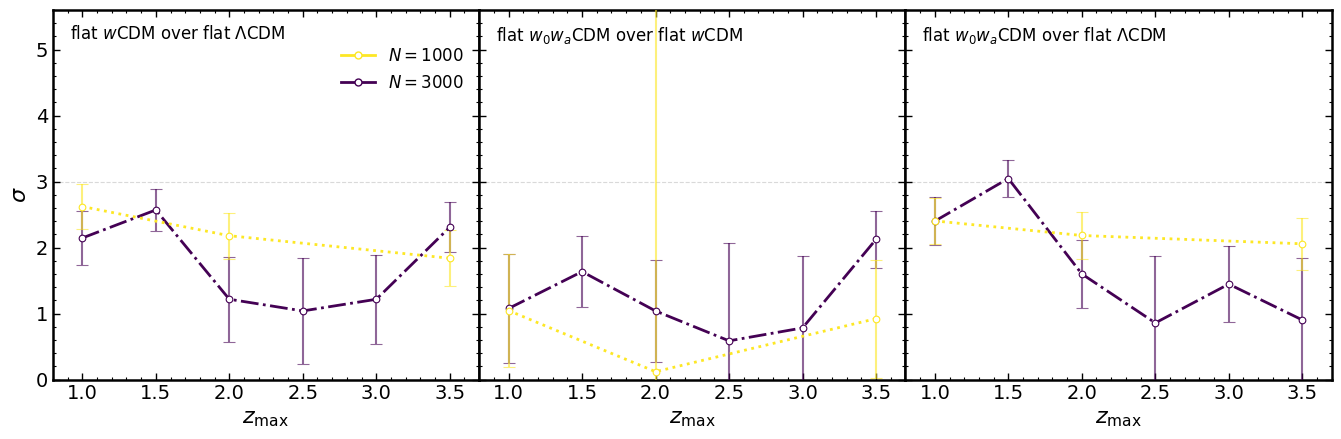

In [12]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl

# ------------------------------------------------------------
# Build comparison table
# ------------------------------------------------------------
df_logZ = df.pivot(index=["N", "z_f"], columns="cosmo_model", values="logZ")
df_logZerr = df.pivot(index=["N", "z_f"], columns="cosmo_model", values="logZerr")

dfw = pd.concat(
    {
        "logZ": df_logZ,
        "logZerr": df_logZerr,
    },
    axis=1,
).reset_index()

# flat wCDM over flat LCDM
res_w_minus_lcdm = odds_sigmas_from_logZ(
    dfw[("logZ", "FlatwCDM")],
    dfw[("logZ", "FlatLambdaCDM")],
    dfw[("logZerr", "FlatwCDM")],
    dfw[("logZerr", "FlatLambdaCDM")],
)
dfw["delta_w_minus_lcdm"] = res_w_minus_lcdm[0]
dfw["deltaerr_w_minus_lcdm"] = res_w_minus_lcdm[1]
dfw["sigma_w_vs_lcdm"] = res_w_minus_lcdm[2]
dfw["sigmaerr_w_vs_lcdm"] = res_w_minus_lcdm[3]

# flat w0waCDM over flat wCDM
res_w0wa_minus_w = odds_sigmas_from_logZ(
    dfw[("logZ", "Flatw0waCDM")],
    dfw[("logZ", "FlatwCDM")],
    dfw[("logZerr", "Flatw0waCDM")],
    dfw[("logZerr", "FlatwCDM")],
)
dfw["delta_w0wa_minus_w"] = res_w0wa_minus_w[0]
dfw["deltaerr_w0wa_minus_w"] = res_w0wa_minus_w[1]
dfw["sigma_w0wa_vs_w"] = res_w0wa_minus_w[2]
dfw["sigmaerr_w0wa_vs_w"] = res_w0wa_minus_w[3]

# flat w0waCDM over flat LCDM
res_w0wa_minus_lcdm = odds_sigmas_from_logZ(
    dfw[("logZ", "Flatw0waCDM")],
    dfw[("logZ", "FlatLambdaCDM")],
    dfw[("logZerr", "Flatw0waCDM")],
    dfw[("logZerr", "FlatLambdaCDM")],
)
dfw["delta_w0wa_minus_lcdm"] = res_w0wa_minus_lcdm[0]
dfw["deltaerr_w0wa_minus_lcdm"] = res_w0wa_minus_lcdm[1]
dfw["sigma_w0wa_vs_lcdm"] = res_w0wa_minus_lcdm[2]
dfw["sigmaerr_w0wa_vs_lcdm"] = res_w0wa_minus_lcdm[3]

dfw = dfw.sort_values(["N", "z_f"]).reset_index(drop=True)

# ------------------------------------------------------------
# Style helpers
# ------------------------------------------------------------
Ns = np.array(sorted(dfw["N"].unique()))

base_cmap = plt.cm.viridis_r
cmap = mpl.colors.ListedColormap(base_cmap(np.linspace(0, 1, len(Ns))))

if len(Ns) > 1:
    boundaries = np.concatenate([
        [Ns[0] - 0.5 * (Ns[1] - Ns[0])],
        0.5 * (Ns[:-1] + Ns[1:]),
        [Ns[-1] + 0.5 * (Ns[-1] - Ns[-2])]
    ])
else:
    boundaries = np.array([Ns[0] - 0.5, Ns[0] + 0.5])

norm = mpl.colors.BoundaryNorm(boundaries, cmap.N)
line_styles = [":", "-.", "--", "-"]

def style_ax(ax, show_xlabel=False, ylabel=None, hide_left_labels=False):
    ax.grid(False)
    ax.minorticks_on()
    ax.tick_params(axis="both", which="major", direction="in", length=5, width=1.0)
    ax.tick_params(axis="both", which="minor", direction="in", length=2.5, width=0.8)
    ax.margins(x=0.0)

    if ylabel is not None:
        ax.set_ylabel(ylabel)

    if show_xlabel:
        ax.set_xlabel(r"$z_{\max}$")
    else:
        ax.tick_params(labelbottom=False)

    if hide_left_labels:
        ax.tick_params(labelleft=False)

def plot_sigma_panel(
    ax,
    ycol,
    yerr_col,
    panel_text,
    show_xlabel=False,
    ylabel=None,
    hide_left_labels=False,
    refline=3.0,
):
    for iN, N in reversed(list(enumerate(Ns))):
        sub = dfw[dfw["N"] == N].sort_values("z_f")
        if sub.empty:
            continue

        color = cmap(norm(N))
        ls = line_styles[iN % len(line_styles)]
        err_color = mpl.colors.to_rgba(color, 0.6)

        ax.errorbar(
            sub["z_f"],
            sub[ycol].to_numpy(),
            yerr=sub[yerr_col].to_numpy(),
            fmt="o",
            linestyle=ls,
            color=color,
            ecolor=err_color,
            lw=2,
            ms=4.8,
            mew=0.8,
            mfc="white",
            elinewidth=1.5,
            capsize=4.0,
            capthick=2.0,
            zorder=3,
        )

    if refline is not None:
        ax.axhline(refline, color="0.85", lw=0.8, ls="--", zorder=1)

    ax.text(
        0.04, 0.96,
        panel_text,
        transform=ax.transAxes,
        ha="left",
        va="top",
        fontsize=12,
    )

    style_ax(
        ax,
        show_xlabel=show_xlabel,
        ylabel=ylabel,
        hide_left_labels=hide_left_labels,
    )

# ------------------------------------------------------------
# Figure: 3 panels, no space between them
# ------------------------------------------------------------
fig, axes = plt.subplots(
    1, 3,
    figsize=(16.5, 4.8),
    sharex=True,
    sharey=True,
    gridspec_kw={"wspace": 0.0},
)
fig.subplots_adjust(wspace=0.0)

plot_sigma_panel(
    axes[0],
    ycol="sigma_w_vs_lcdm",
    yerr_col="sigmaerr_w_vs_lcdm",
    panel_text=r"flat $w$CDM over flat $\Lambda$CDM",
    show_xlabel=True,
    ylabel=r"$\sigma$",
    hide_left_labels=False,
    refline=3.0,
)

plot_sigma_panel(
    axes[1],
    ycol="sigma_w0wa_vs_w",
    yerr_col="sigmaerr_w0wa_vs_w",
    panel_text=r"flat $w_0w_a$CDM over flat $w$CDM",
    show_xlabel=True,
    ylabel=None,
    hide_left_labels=True,
    refline=3.0,
)

plot_sigma_panel(
    axes[2],
    ycol="sigma_w0wa_vs_lcdm",
    yerr_col="sigmaerr_w0wa_vs_lcdm",
    panel_text=r"flat $w_0w_a$CDM over flat $\Lambda$CDM",
    show_xlabel=True,
    ylabel=None,
    hide_left_labels=True,
    refline=3.0,
)

# ------------------------------------------------------------
# Shared limits
# ------------------------------------------------------------
zmin = dfw["z_f"].min()
zmax = dfw["z_f"].max()

for ax in axes:
    ax.set_xlim(zmin - 0.2, zmax + 0.2)
    ax.set_ylim(0, 5.6)

# ------------------------------------------------------------
# Legend for N
# ------------------------------------------------------------
legend_handles = [
    mpl.lines.Line2D(
        [], [],
        color=cmap(norm(n)),
        marker="o",
        lw=2,
        ms=5,
        mfc="white",
        mec=cmap(norm(n)),
        label=fr"$N={int(n)}$"
    )
    for n in Ns
]

axes[0].legend(
    handles=legend_handles,
    loc="upper right",
    bbox_to_anchor=(1.0, 0.94),
    frameon=False,
    ncol=1,
    fontsize=12,
)

# ------------------------------------------------------------
# Save
# ------------------------------------------------------------
os.makedirs("figures/appendix", exist_ok=True)
plt.savefig("figures/appendix/N_vs_logZ_grid.png", dpi=300, bbox_inches="tight")
plt.savefig("figures/appendix/N_vs_logZ_grid.pdf", bbox_inches="tight")
plt.show()

In [13]:
def convert_percentile_bounds_to_errors(
    df,
    params=("Om0", "w0", "wa"),
    lower_suffix="_err_lower",
    upper_suffix="_err_upper",
    inplace=False,
    clip_negative=True,
):
    """
    Convert columns that currently store percentile bounds
    (p16 in *_err_lower and p84 in *_err_upper)
    into true asymmetric errors:
        err_lower = median - p16
        err_upper = p84 - median

    Parameters
    ----------
    df : pandas.DataFrame
        Input table.
    params : iterable of str
        Parameter names whose median is stored in df[param].
    lower_suffix, upper_suffix : str
        Column suffixes for stored p16 and p84 values.
    inplace : bool
        If True, modify df in place. Otherwise return a copy.
    clip_negative : bool
        If True, replace tiny negative values from roundoff with 0.

    Returns
    -------
    pandas.DataFrame
        DataFrame with converted error columns.
    """
    out = df if inplace else df.copy()

    for p in params:
        med_col = p
        lo_col = f"{p}{lower_suffix}"
        hi_col = f"{p}{upper_suffix}"

        if med_col not in out.columns or lo_col not in out.columns or hi_col not in out.columns:
            continue

        p16 = out[lo_col].to_numpy(dtype=float)
        med = out[med_col].to_numpy(dtype=float)
        p84 = out[hi_col].to_numpy(dtype=float)

        err_lower = med - p16
        err_upper = p84 - med

        if clip_negative:
            err_lower = np.maximum(err_lower, 0.0)
            err_upper = np.maximum(err_upper, 0.0)

        out[lo_col] = err_lower
        out[hi_col] = err_upper

    return out

df = convert_percentile_bounds_to_errors(
    df,
    params=("Om0", "w0", "wa"),
    inplace=False,
)

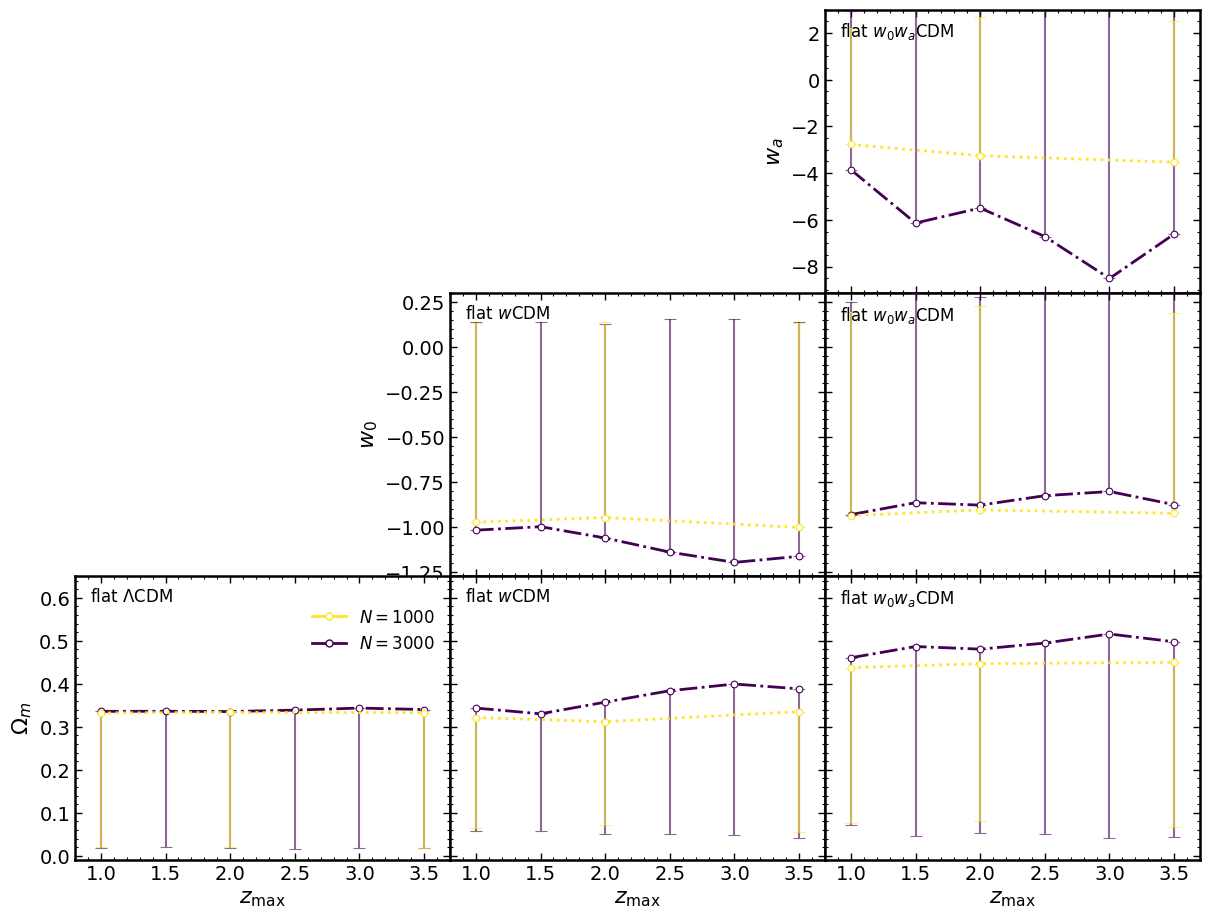

In [14]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl

# ------------------------------------------------------------------
# Assumes df contains at least:
#   N, z_f, cosmo_model,
#   logZ, logZerr,
#   Om0, Om0_err_lower, Om0_err_upper,
#   w0,  w0_err_lower,  w0_err_upper,
#   wa,  wa_err_lower,  wa_err_upper
#
# IMPORTANT:
#   *_err_lower and *_err_upper must be true asymmetric errors:
#       err_lower = median - p16
#       err_upper = p84 - median
# ------------------------------------------------------------------

# ----------------------------
# Style helpers
# ----------------------------

dfp = df.copy().sort_values(["cosmo_model", "N", "z_f"]).reset_index(drop=True)

Ns = np.array(sorted(dfp["N"].unique()))

base_cmap = plt.cm.viridis_r
cmap = mpl.colors.ListedColormap(base_cmap(np.linspace(0, 1, len(Ns))))

if len(Ns) > 1:
    boundaries = np.concatenate([
        [Ns[0] - 0.5 * (Ns[1] - Ns[0])],
        0.5 * (Ns[:-1] + Ns[1:]),
        [Ns[-1] + 0.5 * (Ns[-1] - Ns[-2])]
    ])
else:
    boundaries = np.array([Ns[0] - 0.5, Ns[0] + 0.5])

norm = mpl.colors.BoundaryNorm(boundaries, cmap.N)
line_styles = [":", "-.", "--", "-"]

def style_ax(ax, show_xlabel=False, ylabel=None, hide_left_labels=False):
    ax.grid(False)
    ax.minorticks_on()
    ax.tick_params(axis="both", which="major", direction="in", length=5, width=1.0)
    ax.tick_params(axis="both", which="minor", direction="in", length=2.5, width=0.8)
    ax.margins(x=0.03)

    if ylabel is not None:
        ax.set_ylabel(ylabel)

    if show_xlabel:
        ax.set_xlabel(r"$z_{\max}$")
    else:
        ax.tick_params(labelbottom=False)

    if hide_left_labels:
        ax.tick_params(labelleft=False)

def plot_param_panel(
    ax,
    model,
    ycol,
    yerr_lo_col,
    yerr_hi_col,
    panel_text,
    show_xlabel=False,
    ylabel=None,
    refline=None,
    hide_left_labels=False,
):
    subm = dfp[dfp["cosmo_model"] == model].copy()

    # reverse drawing order
    for iN, N in reversed(list(enumerate(Ns))):
        sub = subm[subm["N"] == N].sort_values("z_f")
        if sub.empty:
            continue

        color = cmap(norm(N))
        ls = line_styles[iN % len(line_styles)]

        yerr = np.vstack([
            sub[yerr_lo_col].to_numpy(),
            sub[yerr_hi_col].to_numpy(),
        ])
        err_alpha = 0.6

        err_color = mpl.colors.to_rgba(color, err_alpha)

        ax.errorbar(
            sub["z_f"],
            sub[ycol].to_numpy(),
            yerr=yerr,
            fmt="o",
            linestyle=ls,
            color=color,
            ecolor=err_color,
            lw=2,
            ms=4.8,
            mew=0.8,
            mfc="white",
            elinewidth=1.5,
            capsize=4.0,
            capthick=2.0,
            zorder=3,
        )

    ax.text(
        0.04, 0.96,
        panel_text,
        transform=ax.transAxes,
        ha="left",
        va="top",
        fontsize=12,
    )

    style_ax(
        ax,
        show_xlabel=show_xlabel,
        ylabel=ylabel,
        hide_left_labels=hide_left_labels,
    )
# ----------------------------
# Figure layout: corner-like half grid
# ----------------------------
fig = plt.figure(figsize=(12.5, 10.0))
gs = fig.add_gridspec(
    3, 3,
    left=0.08, right=0.98, bottom=0.08, top=0.93,
    wspace=0.0, hspace=0.0
)

# Top row: wa (1 panel)
ax_wa = fig.add_subplot(gs[0, 2])

# Row 2: w0 (share y within row)
ax_w0_w = fig.add_subplot(gs[1, 1])
ax_w0_w0wa = fig.add_subplot(gs[1, 2], sharey=ax_w0_w)

# Row 3: Om0 (share y within row)
ax_om_lcdm = fig.add_subplot(gs[2, 0])
ax_om_w = fig.add_subplot(gs[2, 1], sharey=ax_om_lcdm)
ax_om_w0wa = fig.add_subplot(gs[2, 2], sharey=ax_om_lcdm)

# ----------------------------
# Plot rows
# ----------------------------

# wa
plot_param_panel(
    ax_wa,
    model="Flatw0waCDM",
    ycol="wa",
    yerr_lo_col="wa_err_lower",
    yerr_hi_col="wa_err_upper",
    panel_text=r"flat $w_0w_a$CDM",
    show_xlabel=False,
    ylabel=r"$w_a$",
    refline=0.0,
    hide_left_labels=False,
)

# w0
plot_param_panel(
    ax_w0_w,
    model="FlatwCDM",
    ycol="w0",
    yerr_lo_col="w0_err_lower",
    yerr_hi_col="w0_err_upper",
    panel_text=r"flat $w$CDM",
    show_xlabel=False,
    ylabel=r"$w_0$",
    refline=-1.0,
    hide_left_labels=False,
)

plot_param_panel(
    ax_w0_w0wa,
    model="Flatw0waCDM",
    ycol="w0",
    yerr_lo_col="w0_err_lower",
    yerr_hi_col="w0_err_upper",
    panel_text=r"flat $w_0w_a$CDM",
    show_xlabel=False,
    ylabel=None,
    refline=-1.0,
    hide_left_labels=True,
)

# Om0
plot_param_panel(
    ax_om_lcdm,
    model="FlatLambdaCDM",
    ycol="Om0",
    yerr_lo_col="Om0_err_lower",
    yerr_hi_col="Om0_err_upper",
    panel_text=r"flat $\Lambda$CDM",
    show_xlabel=True,
    ylabel=r"$\Omega_m$",
    refline=0.311,
    hide_left_labels=False,
)

plot_param_panel(
    ax_om_w,
    model="FlatwCDM",
    ycol="Om0",
    yerr_lo_col="Om0_err_lower",
    yerr_hi_col="Om0_err_upper",
    panel_text=r"flat $w$CDM",
    show_xlabel=True,
    ylabel=None,
    refline=0.311,
    hide_left_labels=True,
)

plot_param_panel(
    ax_om_w0wa,
    model="Flatw0waCDM",
    ycol="Om0",
    yerr_lo_col="Om0_err_lower",
    yerr_hi_col="Om0_err_upper",
    panel_text=r"flat $w_0w_a$CDM",
    show_xlabel=True,
    ylabel=None,
    refline=0.311,
    hide_left_labels=True,
)

# ----------------------------
# Legend for N
# ----------------------------
legend_handles = [
    mpl.lines.Line2D(
        [], [],
        color=cmap(norm(n)),
        marker="o",
        lw=2,
        ms=5,
        mfc="white",
        mec=cmap(norm(n)),
        label=fr"$N={int(n)}$"
    )
    for n in Ns
]

# ----------------------------
# Shared x-limits for all visible panels
# ----------------------------
zmin = df["z_f"].min()
zmax = df["z_f"].max()

for ax in [
    ax_wa,
    ax_w0_w, ax_w0_w0wa,
    ax_om_lcdm, ax_om_w, ax_om_w0wa,
]:
    ax.set_xlim(zmin-0.2, zmax+0.2)

ax_om_w0wa.set_ylim(top=0.65)
ax_w0_w.set_ylim(top=0.3)
ax_wa.set_ylim(top=3)

ax_om_lcdm.legend(
    handles=legend_handles,
    loc="upper right",
    bbox_to_anchor=(1.0, 0.94),
    frameon=False,
    ncol=1,
    fontsize=12,
)

# ----------------------------
# Save
# ----------------------------
os.makedirs("figures/appendix", exist_ok=True)
plt.savefig("figures/appendix/N_vs_cosmo_corner_grid.png", dpi=300, bbox_inches="tight")
plt.savefig("figures/appendix/N_vs_cosmo_corner_grid.pdf", bbox_inches="tight")
plt.show()